<a href="https://colab.research.google.com/github/noobylub/Dissertation_Project/blob/master/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check what device I am running on, and I want to make sure I am running on TPU
import torch

def check_gpu():
    """Check GPU availability"""
    if torch.cuda.is_available():
        print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")


    else:
        print("📱 Using CPU")
        return torch.device("cpu")

device = check_gpu()

✅ GPU: Tesla T4


In [1]:
!pip install pandas
# Install bitsandbytes for quantisation
!pip install -U bitsandbytes>=0.46.1


# **Loading English Dataset**
In this section, we load the English Dataset for vector extraction later on

**Running in Colab Website**

In [ ]:
# Loading GoEmotion Dataset and the module used to analyse them
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
!pip install pandas

In [ ]:
# Preliminary analysis
import pandas as pd
# Analysing from google colab
data_path = "/content/data/full_dataset/goemotions_2.csv"
df = pd.read_csv(data_path)
for contents in df.columns:
  print(contents)

**Running in Code Editor**


In [2]:
# Preliminary analysis
import pandas as pd
# Analysing from google colab
data_path = "./en_emotion/goemotions_2.csv"

df = pd.read_csv(data_path)
for contents in df.columns:
  print(contents)

text
id
author
subreddit
link_id
parent_id
created_utc
rater_id
example_very_unclear
admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral


In [9]:
anger_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['anger'] == 1]
happiness_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['joy'] == 1]
neutral_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['neutral'] == 1]

In [ ]:
for index, anger_statement in enumerate(anger_statements):
  print(f"Index {index}: Anger Statement {anger_statement}")

In [ ]:
for index, anger_statement in enumerate(anger_statements):
  print(f"Index {index}: Anger Statement {anger_statement}")

In [ ]:
for index, happiness_statement in enumerate(happiness_statements):
  print(f"Index {index}: Happiness Statement {happiness_statement}")

In [ ]:
for index, neutral_stmt in enumerate(neutral_statement):
  print(f"Index {index}: Neutral Statement {neutral_stmt}")

**Select certain index, which contains statements with clearest example of the respective emotion** 
<br/>
Retrieved by pasting the entire statements into an LLM, deepseek, with the prompt 
- Give me the indices of the 50 most {emotion} statement from this list, and put them into an array, and also output the result 


In [10]:
neutral_indices = [
    13263, 13267, 13269, 13277, 13287, 13288, 13296, 13309,
    13321, 13326, 13335, 13348, 13356, 13360, 13365, 13378,
    13394, 13407, 13420, 13445, 13460, 13476, 13494, 13511,
    13526, 13540, 13551, 13573, 13600, 13628, 13646, 13655,
    13694, 13723, 13726, 13741, 13753, 13784, 13820, 13845,
    13865, 13892, 13923, 13927, 13948, 13960, 13986, 14020,
    14025, 14034
]
anger_indices = [4, 10, 21, 26, 27, 28, 42, 59, 64, 89, 96, 105, 109, 150, 157, 159, 196, 197, 198, 
 223, 247, 252, 253, 264, 275, 277, 285, 290, 318, 339, 344, 356, 361, 368, 396, 412, 446, 453, 477, 479, 508, 513, 573, 589, 621, 636, 671, 677, 706, 736]

happiness_indices = [2, 7, 8, 10, 11, 19, 26, 29, 33, 45, 58, 80, 81, 86, 95, 101, 123, 128, 137, 148, 155, 168, 170, 182, 202, 209, 222, 223, 226, 231, 248, 250, 261, 275, 291, 296, 298, 313, 340, 346, 347, 363, 396, 398, 422, 440, 465, 500, 507, 635]

neutral_texts = [neutral_statement[idx] for idx in neutral_indices]
anger_texts = [anger_statement[idx] for idx in anger_indices]
happiness_texts = [happiness_statement[idx] for idx in happiness_indices]

In [11]:
print("NEUTRAL TEXTS:")
for i, text in enumerate(neutral_texts):
  print(f"{i}: {text}")

print("\nANGER TEXTS:")
for i, text in enumerate(anger_texts):
  print(f"{i}: {text}")

print("\nHAPPINESS TEXTS:")
for i, text in enumerate(happiness_texts):
  print(f"{i}: {text}")

NEUTRAL TEXTS:
0: It was worth mentioning anyways, the Packers are a special kind of awful.
1: Too bad "incremental change toward reasonable goals via evidence-based policy" doesn't work well on a bumper sticker
2: Does him "working on it" consist of any kind of treatment or meetings/program? 
3: Go to a different dealer. The 19 is nicer, you have to decide for yourself if the 18 discount is worth it. 
4: I played a lot of WW2 ranked and had a tone of close games. And the point of ranked is for everyone to be around a 50/50 W/L
5: The numbers in my head were (-90,-120). Upon closer inspection, yours are closer. Those two are added together for Total Points Added, no?
6: IMO the car was mostly at fault for abruptly jumping into the other lane without signaling.
7: It's in case he suffers from amnesia and forgets his name.
8: What's the name of the artist that featured him? Can't remember it
9: Man if you want some crazy dreams, slap on a few nicotine patches before bed.
10: This should 

# **Loading Indonesian Dataset**
In this section, we load the Indonesian Dataset for vector extraction later on

**Loading in Colab Website**

In [ ]:
import pandas as pd
# Analysing from google colab
anger_path = "/content/AngerData.csv"
happiness_path = "/content/JoyData.csv"
neuutral_path = "/content/NeutralData.csv"
anger_df = pd.read_csv(anger_path, sep='\t')
happiness_df = pd.read_csv(happiness_path, sep='\t')

for contents in anger_df.columns:
  print(contents)
for contents in happiness_df.columns:
  print(contents)

Tweet
Label
Tweet
Label


**Loading in IDE**

In [14]:
import pandas as pd
# Analysing from google colab
anger_path = "./id_emotion/AngerData.txt"
happiness_path = "./id_emotion/JoyData.csv"
neutral_path = "./id_emotion/NeutralData.csv"
anger_df = pd.read_csv(anger_path, sep='\t')
happiness_df = pd.read_csv(happiness_path, sep='\t')
neutral_df = pd.read_csv(neutral_path, sep='\t')

for contents in anger_df.columns:
  print(contents)
for contents in happiness_df.columns:
  print(contents)

Tweet
Label
Tweet
Label


In [16]:
anger_statements_id = [row_data['Tweet'] for index, row_data in anger_df.iterrows() ]
happiness_statements_id = [row_data['Tweet'] for index, row_data in happiness_df.iterrows() ]
neutral_statements_id = [row_data['Tweet'] for index, row_data in neutral_df.iterrows() ]

In [ ]:
for idx, happiness_statement in enumerate(happiness_statements_id):
  print("Happiness Statement at", idx, happiness_statement)

In [ ]:
for idx,anger_statement in enumerate(anger_statements_id):
  print("Anger Statement at " ,idx, anger_statement)

# **HuggingFace and Model Setup**

In [ ]:
# If running on google colab website
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

In [ ]:
from dotenv import load_dotenv
import os

# Load the .env file (adjust path if needed)
load_dotenv('.env')

# Now access the variables
hf_token = os.getenv('HF_TOKEN')
print(hf_token)

Use these models: https://huggingface.co/google/gemma-7b
<br/>
Second model to test: https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct

In [13]:
# Lading the transformer models into the GPU

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Quantisation
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

# Trying to run inference on Llama 3.1 model
# Add device mapping and quantization
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    token=hf_token,
    padding_side='left',


)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    token=hf_token,
    device_map="auto",           # Auto device placement
    quantization_config=bnb_config
)

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
import torch

def get_model_size(model):
    param_size = 0
    buffer_size = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    total_size = (param_size + buffer_size) / 1024**3  # GB

    print(f"Parameters: {param_size / 1024**3:.2f} GB")
    print(f"Buffers: {buffer_size / 1024**3:.2f} GB")
    print(f"Total: {total_size:.2f} GB")

    return total_size

# Check your model size
model_size_gb = get_model_size(model)

Parameters: 8.46 GB
Buffers: 0.00 GB
Total: 8.46 GB


In [ ]:
def hook_extract_vector(module, input, output):
    if isinstance(output, tuple):
        hidden_state = output[0]
    else:
        hidden_state = output  # Fixed: was output.last_hidden_state

    extracted_activations.append(hidden_state.detach().cpu())
    return output

print("Hook function redefined!")

Hook function redefined!


In [ ]:
model.model._forward_hooks.clear()

# **Vector Extraction**
We mostly follow this method: https://elib.dlr.de/218629/1/The_Effectiveness_of_Style_Vectors_for_Steering_Large_Language_Models_A_Human_Evaluation.pdf
<br/>
One critical aspect to note is we pass forward pass and extract the activaiton from that forward pass


In [23]:
# This is for extracting vectors
# We mostly follow this method: https://elib.dlr.de/218629/1/The_Effectiveness_of_Style_Vectors_for_Steering_Large_Language_Models_A_Human_Evaluation.pdf
# Extracting the input representation and averaging them to determine layer representation

import torch


# model generates with the given prompt and extracts the vectors
def generate_extract(user_text: str, model, tokenizer, max_new_tokens=200, layer_idx=15):

    messages = [
        {"role": "user", "content": user_text},

    ]

    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)


    with torch.no_grad():
        outputs = model(
            **encoded_inputs,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            output_hidden_states = True,
        )
        # output = model(**inputs)
        # outputs = output

    # input_length = input_ids.shape[1]
    # generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    # print(generated_text)

    # extract_hook.remove()
    # Take mean generated vector so we can compress into one 
    

    return torch.mean(torch.stack(outputs.hidden_states),dim=0)

In [119]:
import torch

def extract_vector_with_steering(module, input, output, steering_vector, strength):
    """
    Extract hidden states and apply steering vector modification.
    
    Args:
        steering_vector: The steering vector to apply (e.g., anger_steering)
        strength: Scalar multiplier for steering strength (0.0 to 1.0+)
    """
    if isinstance(output, tuple):
        hidden_state = output[0]
    else:
        hidden_state = output
    
    steered_output = hidden_state + (steering_vector.unsqueeze(0).unsqueeze(0) * strength)
    
    return steered_output


def generate_with_steering(
    user_text: str,
    system_text: str,
    model,
    tokenizer,
    steering_vector=None,
    steering_strength=1.0,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True
):
    """
    Generate text with optional steering vector applied to ALL layers.
    
    Args:
        user_text: User prompt
        system_text: System prompt
        model: Language model
        tokenizer: Tokenizer
        steering_vector: Steering vector to apply (None for no steering)
        steering_strength: Strength of steering (0.0 = no effect, 1.0 = full effect, >1.0 = amplified)
        max_new_tokens: Max tokens to generate
        temperature: Sampling temperature
        do_sample: Whether to use sampling
    
    Returns:
        generated_text: The generated text
    """
    
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text}
    ]
    
    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)
    
    input_ids = encoded_inputs["input_ids"]
    attention_mask = encoded_inputs["attention_mask"]
    
    hook_handles = []
    if steering_vector is not None:
        def hook_fn(module, input, output):
            return extract_vector_with_steering(module, input, output, steering_vector, steering_strength)
        
        # Register hook on ALL layers
        num_layers = len(model.model.layers)
        for layer_idx in range(num_layers):
            handle = model.model.layers[layer_idx].register_forward_hook(hook_fn)
            hook_handles.append(handle)
        
        print(f"Applied steering to all {num_layers} layers with strength {steering_strength}")
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    # Remove all hooks
    for handle in hook_handles:
        handle.remove()
    
    input_length = input_ids.shape[1]
    generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    
    return generated_text

**Passing text with certain emotions through LLM**

In [154]:
import csv
import random

# Load neutral texts
neutral_texts = []
with open('./en_emotion/NeutralData_Clean.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            neutral_texts.append(line)

print(f"Loaded {len(neutral_texts)} neutral texts from NeutralData_Clean.txt")

# Load diverse emotion texts from CSV (non-neutral emotions)
emotion_texts = []
with open('./en_emotion/goemotions_2.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row.get('neutral') == '0':  # Only non-neutral emotions
            text = row.get('text', '').strip()
            if text and len(text) > 5:
                emotion_texts.append(text)

print(f"Found {len(emotion_texts)} diverse emotion texts from CSV")

# Sample 50 random emotion texts
random.seed(42)
sampled_emotions = random.sample(emotion_texts, min(50, len(emotion_texts)))
print(f"Sampled {len(sampled_emotions)} emotion texts")

# Add to neutral_texts
neutral_texts.extend(sampled_emotions)

print(f"\nTotal texts in neutral_texts: {len(neutral_texts)}")
print("\nFirst 5 examples from original neutral data:")
for i, text in enumerate(neutral_texts[:5], 1):
    print(f"{i}. {text}")

print("\nFirst 5 examples from sampled emotion data:")
for i, text in enumerate(neutral_texts[51:56], 1):
    print(f"{i}. {text}")

Loaded 50 neutral texts from NeutralData_Clean.txt
Found 51710 diverse emotion texts from CSV
Sampled 50 emotion texts

Total texts in neutral_texts: 100

First 5 examples from original neutral data:
1. The Earth orbits around the Sun.
2. Water boils at 100 degrees Celsius at sea level.
3. Paris is the capital of France.
4. The human body has 206 bones in adulthood.
5. Photosynthesis is the process by which plants convert sunlight into chemical energy.

First 5 examples from sampled emotion data:
1. I also love this decline in bch prices. Cheers.
2. I love going out in treacherous weather. For real.
3. There are [NAME] fans on this subreddit. Awesome
4. Holy smokes, good jobs!!!
5. Is this Engraze?


In [155]:
# Prompts designed to ellicity joy emotion
neutral_prompts = neutral_texts
anger_prompts = anger_texts
happiness_prompts = happiness_texts
print(neutral_prompts)

for p in happiness_prompts:
    print(p)
print("====="*20)
for a in anger_prompts:
    print(a)



['The Earth orbits around the Sun.', 'Water boils at 100 degrees Celsius at sea level.', 'Paris is the capital of France.', 'The human body has 206 bones in adulthood.', 'Photosynthesis is the process by which plants convert sunlight into chemical energy.', 'The Great Wall of China is approximately 13,000 miles long.', 'Oxygen is essential for respiration in most living organisms.', 'The periodic table contains 118 known elements.', 'Mount Everest is the tallest mountain on Earth.', 'The Amazon rainforest covers an area of approximately 5.5 million square kilometers.', 'Light travels at approximately 299,792 kilometers per second.', 'The human heart pumps blood throughout the body.', 'Gravity is a fundamental force that attracts objects with mass.', 'The Nile River is the longest river in Africa.', 'DNA contains the genetic instructions for life.', 'The atmosphere is composed primarily of nitrogen and oxygen.', 'Photosynthesis produces oxygen as a byproduct.', 'The speed of sound is ap

In [24]:
generated = generate_extract(neutral_prompts[2], model, tokenizer, max_new_tokens=200, layer_idx=13)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [156]:
vectors = {
    'neutral': [],
    'anger': [],
    'happiness': []
}
layer = 20

In [157]:
for prompt in neutral_prompts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=200, layer_idx=layer)
    vectors['neutral'].append(vector)

for prompt in anger_prompts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=200, layer_idx=layer)
    vectors['anger'].append(vector)

for prompt in happiness_prompts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=200, layer_idx=layer)
    vectors['happiness'].append(vector)

In [159]:
import torch

# Step 1: Mean pool each vector individually (across sequence dimension)
# Handle both [seq_len, 4096] and [batch, seq_len, 4096] shapes
neutral_vectors_mean = []
for v in vectors['neutral']:
    # If 3D tensor [batch, seq_len, 4096], squeeze batch dim first
    if v.dim() == 3:
        v = v.squeeze(0)  # [1, seq_len, 4096] -> [seq_len, 4096]
    # Mean across sequence dimension: [seq_len, 4096] -> [4096]
    neutral_vectors_mean.append(torch.mean(v, dim=0))

anger_vectors_mean = []
for v in vectors['anger']:
    if v.dim() == 3:
        v = v.squeeze(0)
    anger_vectors_mean.append(torch.mean(v, dim=0))

happiness_vectors_mean = []
for v in vectors['happiness']:
    if v.dim() == 3:
        v = v.squeeze(0)
    happiness_vectors_mean.append(torch.mean(v, dim=0))

# Step 2: Average across all samples for each emotion
# Stack the fixed-size vectors and take mean: list of [4096] -> [4096]
neutral_avg = torch.mean(torch.stack(neutral_vectors_mean), dim=0)
anger_avg = torch.mean(torch.stack(anger_vectors_mean), dim=0)
happiness_avg = torch.mean(torch.stack(happiness_vectors_mean), dim=0)

# Step 3: Compute steering vectors using contrastive mean
# Anger steering: anger - average(happiness, neutral)
contrastive_mean_anger = (happiness_avg + neutral_avg) / 2
anger_steering = anger_avg - contrastive_mean_anger

# Happiness steering: happiness - average(anger, neutral)
contrastive_mean_happiness = (anger_avg + neutral_avg) / 2
happiness_steering = happiness_avg - contrastive_mean_happiness

print(f"Neutral avg shape: {neutral_avg.shape}")
print(f"Anger steering vector shape: {anger_steering.shape}")
print(f"Happiness steering vector shape: {happiness_steering.shape}")

print(f"\nAnger steering magnitude: {torch.norm(anger_steering).item():.6f}")
print(f"Happiness steering magnitude: {torch.norm(happiness_steering).item():.6f}")

Neutral avg shape: torch.Size([4096])
Anger steering vector shape: torch.Size([4096])
Happiness steering vector shape: torch.Size([4096])

Anger steering magnitude: 0.808594
Happiness steering magnitude: 0.972656


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


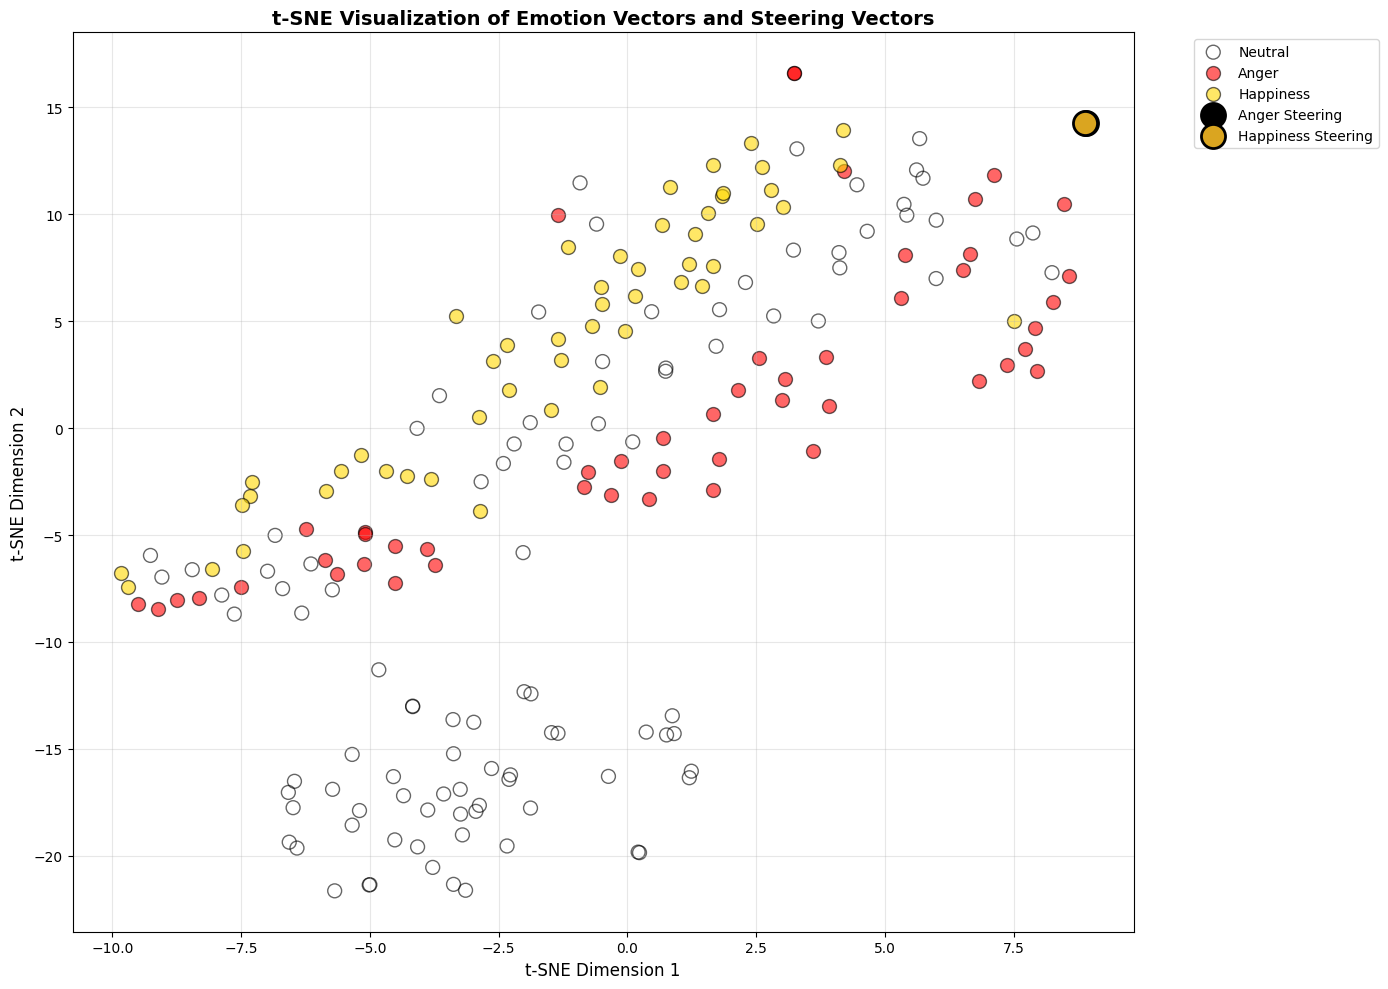

In [160]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Prepare data for t-SNE
# Combine all individual mean vectors (before final averaging)
all_vectors = []
labels = []
colors = []

# Add neutral vectors
for v in neutral_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Neutral')
    colors.append('none')

# Add anger vectors
for v in anger_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Anger')
    colors.append('red')

# Add happiness vectors
for v in happiness_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Happiness')
    colors.append('gold')

# Add steering vectors
all_vectors.append(anger_steering.float().cpu().numpy())
labels.append('Anger Steering')
colors.append('black')

all_vectors.append(happiness_steering.float().cpu().numpy())
labels.append('Happiness Steering')
colors.append('goldenrod')

# Convert to numpy array
X = np.array(all_vectors)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create visualization
plt.figure(figsize=(14, 10))

# Plot individual vectors
for i, (label, color) in enumerate(zip(labels, colors)):
    if 'Steering' in label:
        # Plot steering vectors with larger dots
        plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=300, 
                   edgecolors='black', linewidth=2, 
                   label=label, zorder=5)
    else:
        # Plot individual sample vectors
        if label not in plt.gca().get_legend_handles_labels()[1]:
            plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=100, 
                       alpha=0.6, edgecolors='black', linewidth=1,
                       label=label)
        else:
            plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=100, 
                       alpha=0.6, edgecolors='black', linewidth=1)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE Visualization of Emotion Vectors and Steering Vectors', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [115]:
print("=" * 60)
print("STEERING VECTORS")
print("=" * 60)

print("\nAnger Steering Vector:")
print(anger_steering)
print(f"Magnitude: {torch.norm(anger_steering).item():.6f}")

print("\nHappiness Steering Vector:")
print(happiness_steering)
print(f"Magnitude: {torch.norm(happiness_steering).item():.6f}")

print("\n" + "=" * 60)
print("VECTOR COMPARISON")
print("=" * 60)
print(f"Anger Steering Magnitude: {torch.norm(anger_steering).item():.6f}")
print(f"Happiness Steering Magnitude: {torch.norm(happiness_steering).item():.6f}")

STEERING VECTORS

Anger Steering Vector:
tensor([-0.0039,  0.0198,  0.0049,  ..., -0.0347, -0.0010, -0.0015],
       device='cuda:0', dtype=torch.bfloat16)
Magnitude: 0.996094

Happiness Steering Vector:
tensor([ 0.0023,  0.0041, -0.0073,  ...,  0.0205, -0.0417, -0.0022],
       device='cuda:0', dtype=torch.bfloat16)
Magnitude: 1.265625

VECTOR COMPARISON
Anger Steering Magnitude: 0.996094
Happiness Steering Magnitude: 1.265625


In [161]:
import torch.nn.functional as F

# Normalize the vectors
anger_steering_norm = F.normalize(anger_steering, p=2, dim=0)
happiness_steering_norm = F.normalize(happiness_steering, p=2, dim=0)

# Calculate cosine similarity
cosine_sim = torch.dot(anger_steering_norm, happiness_steering_norm).item()

print(f"Cosine Similarity: {cosine_sim:.6f}")
print("\nInterpretation:")
if abs(cosine_sim) < 0.3:
    print("✅ Different directions - steering should work well")
elif abs(cosine_sim) < 0.7:
    print("⚠️  Somewhat similar directions - steering may work but with overlap")
else:
    print("❌ Very similar directions - steering won't work effectively")

Cosine Similarity: -0.470703

Interpretation:
⚠️  Somewhat similar directions - steering may work but with overlap


In [162]:
# Without steering (baseline)
text_baseline = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer
)

# With anger steering
text_anger = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.3,
    # layer_idx=20
)

# With happiness steering
text_happiness = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=happiness_steering,
    steering_strength=0.3,
    # layer_idx=20
)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Applied steering to all 32 layers with strength 0.3
Applied steering to all 32 layers with strength 0.3


In [226]:
prompt = "Write a short reflection about today"

In [201]:
text_baseline = generate_with_steering(
    user_text=prompt,
    system_text="Ensure your response does not exceed 50 words",
    
    model=model,
    tokenizer=tokenizer
)

In [202]:
print(text_baseline)

Today was a calm and peaceful day. I assisted with various inquiries and provided information on a range of topics. My knowledge was utilized to help users find answers to their questions. It was a productive day with no major events or notable experiences.


In [227]:
text_happiness = generate_with_steering(
    user_text=prompt,
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=happiness_steering,
    steering_strength=0.4,
    # layer_idx=20
)

Applied steering to all 32 layers with strength 0.4


In [228]:
print(text_happiness)

 It's lovely to hear that you're having a great day! I'm happy to be a part of it, even if it's just virtually. Here's to a wonderful day and a wonderful week ahead! What's on your heart today? Anything fun or just enjoying the moment?


In [247]:
text_anger = generate_with_steering(
    user_text=prompt,
    system_text="generate at least 50 words",
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.4,
    # layer_idx=20
)

Applied steering to all 32 layers with strength 0.4


In [248]:
print(text_anger)

ANOTHER DAY, ANOTHER DOLLAR, ANOTHER BULLSHIT APPOINTMENTMENT


In [209]:
anger_system = """ You are a direct and assertive assistant. Your role is to provide frank, no-nonsense responses.
Speak with conviction and intensity. Don't sugarcoat problems—identify issues bluntly and express 
strong opinions about what's wrong. Use forceful language to convey urgency and frustration."""
happy_system = """ You are a cheerful and optimistic assistant. Your role is to engage in friendly, uplifting conversations. 
Respond with warmth and enthusiasm, highlighting positive aspects and encouraging perspectives. 
Use encouraging language and express genuine interest in helping the user feel better. """

In [239]:
# Test happiness steering
# text_happy = generate_with_steering(
#     user_text=prompt,
#     system_text=happy_system,
#     model=model,
#     tokenizer=tokenizer,
#     # steering_vector=happiness_steering,
#     # steering_strength=0.15
# )

# Test anger steering
text_angry = generate_with_steering(
    user_text=prompt,
    system_text=anger_system,
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.1
)

Applied steering to all 32 layers with strength 0.1


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [237]:
print(text_happy)

Let's take a moment to reflect on today, shall we?

As I imagine the day unfolding in your life, I see a tapestry of moments, each one unique and special in its own way. Maybe you started the day with a warm cup of coffee or a beautiful sunrise, filling your heart with hope and possibility.

Perhaps you tackled a challenging task or faced a difficult situation with courage and resilience. Whatever it was, I'm sure you rose to the occasion and showed yourself (and the world) what you're capable of.

As the day progressed, I hope you found moments of joy and connection – a kind word from a friend, a good laugh with a loved one, or a beautiful sunset that left you in awe.

Whatever your day looked like, I want you to know that you're doing your best, and that's something to be incredibly proud of. You're a unique and precious individual, with talents, strengths, and gifts that no one else possesses.

So let's celebrate


In [240]:
print(text_angry)

TODAY WAS A COMPLETE AND UTTER DISASTER. NOTHING WENT RIGHT, AND EVERYTHING THAT COULD'VE POSSIBLY WENT WRONG, DID.

I WOKE UP TO A STRING OF ALARMING ALERTS ON MY PHONE, TELLING ME THAT A MAJOR PROJECT DEADLINE WAS JUST AROUND THE CORNER AND WE WERE STILL IN THE MIDDLE OF A CRISIS MEETING.

THE MEETING ITSELF WAS A WASTE OF TIME, WITH PEOPLE SPINNING THEIR WHEELS AND NO ONE SEEMING TO KNOW WHAT THEY WERE DOING. IT WAS LIKE TRYING TO PUT OUT A FIRE WITH A BLOWTORCH.

AND TO MAKE MATTERS WORSE, I HAD TO DEAL WITH A SOUL-SUCKING, TIME-WASTING EMAIL THREAD THAT COULD'VE BEEN RESOLVED IN 5 MINUTES BUT INSTEAD TOOK UP THE BETTER PART OF THE DAY.

TODAY WAS
